# Feature Importance em Árvores

Prática comparando os métodos de feature importance em modelos de árvore: MDI (`feature_importances_`), permutation importance (treino vs. teste), os três rankings nativos do XGBoost (`weight`, `gain`, `cover`) e SHAP (TreeSHAP), sobre um dataset de regressão simulado com armadilhas plantadas de propósito: uma feature de ruído puro, uma categórica de alta cardinalidade aleatória e uma feature duplicada de uma das fortes.

## 1. Importação das bibliotecas

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

DRACULA_BACKGROUND = "#282a36"
DRACULA_FOREGROUND = "#f8f8f2"
DRACULA_GRID = "#44475a"

sns.set_theme(
    style="darkgrid",
    rc={
        "figure.figsize": (8, 5),
        "axes.spines.right": False,
        "axes.spines.top": False,
        "figure.facecolor": DRACULA_BACKGROUND,
        "axes.facecolor": DRACULA_BACKGROUND,
        "savefig.facecolor": DRACULA_BACKGROUND,
        "text.color": DRACULA_FOREGROUND,
        "axes.labelcolor": DRACULA_FOREGROUND,
        "xtick.color": DRACULA_FOREGROUND,
        "ytick.color": DRACULA_FOREGROUND,
        "axes.edgecolor": DRACULA_GRID,
        "grid.color": DRACULA_GRID,
    },
)

RANDOM_SEED = 42

## 2. Simulação dos dados

Dataset de regressão simulando renda mensal a partir de três features legítimas (`anos_experiencia`, `anos_educacao`, `idade`), com três armadilhas plantadas de propósito:

- `ruido_puro`: ruído gaussiano sem nenhuma relação com o target, para ver se algum método lhe atribui importância não-nula.
- `codigo_agencia`: categórica de alta cardinalidade (300 códigos aleatórios), sem relação com o target, para expor o viés do MDI e do ranking `weight` do XGBoost por número de splits.
- `anos_experiencia_duplicada`: cópia exata de `anos_experiencia`, para testar como a importância se dilui entre uma feature forte e sua duplicata.

In [75]:
def simular_idade(rng, minimo, maximo, n):
    return rng.integers(minimo, maximo + 1, n)


def simular_anos_educacao(rng, anos_disponiveis, media, desvio):
    return np.clip(rng.normal(media, desvio, len(anos_disponiveis)), 0, anos_disponiveis)


def simular_anos_experiencia(rng, anos_disponiveis, anos_educacao, media, desvio):
    limite_superior = anos_disponiveis - anos_educacao
    return np.clip(rng.normal(media, desvio, len(anos_disponiveis)), 0, limite_superior)


def simular_renda_mensal(rng, anos_experiencia, anos_educacao, idade, base, coef_experiencia, coef_educacao, coef_idade_log, noise_std):
    return (
        base
        + coef_experiencia * anos_experiencia
        + coef_educacao * anos_educacao
        + coef_idade_log * np.log1p(idade)
        + rng.normal(0, noise_std, len(idade))
    )


def montar_features(anos_experiencia, anos_educacao, idade, ruido_puro, codigo_agencia):
    return pd.DataFrame({
        "anos_experiencia": anos_experiencia,
        "anos_educacao": anos_educacao,
        "idade": idade,
        "ruido_puro": ruido_puro,
        "codigo_agencia": codigo_agencia,
        "anos_experiencia_duplicada": anos_experiencia.copy(),
    })


rng = np.random.default_rng(RANDOM_SEED)

N_SAMPLES = 3000

EXPERIENCIA_MEAN = 10
EXPERIENCIA_STD = 5
EDUCACAO_MEAN = 12
EDUCACAO_STD = 3
IDADE_MIN = 22
IDADE_MAX = 65
IDADE_INICIO_ESCOLA = 5

RENDA_BASE = 2000
COEF_EXPERIENCIA = 350
COEF_EDUCACAO = 180
COEF_IDADE_LOG = 800
RENDA_NOISE_STD = 1500

N_CATEGORIAS_AGENCIA = 300

idade = simular_idade(rng, IDADE_MIN, IDADE_MAX, N_SAMPLES)
anos_disponiveis = idade - IDADE_INICIO_ESCOLA
anos_educacao = simular_anos_educacao(rng, anos_disponiveis, EDUCACAO_MEAN, EDUCACAO_STD)
anos_experiencia = simular_anos_experiencia(rng, anos_disponiveis, anos_educacao, EXPERIENCIA_MEAN, EXPERIENCIA_STD)

renda_mensal = simular_renda_mensal(
    rng, anos_experiencia, anos_educacao, idade,
    RENDA_BASE, COEF_EXPERIENCIA, COEF_EDUCACAO, COEF_IDADE_LOG, RENDA_NOISE_STD,
)

ruido_puro = rng.normal(0, 1, N_SAMPLES)
codigo_agencia = rng.integers(0, N_CATEGORIAS_AGENCIA, N_SAMPLES)

features = montar_features(anos_experiencia, anos_educacao, idade, ruido_puro, codigo_agencia)
target = pd.Series(renda_mensal, name="renda_mensal")

features.head()

,anos_experiencia,anos_educacao,idade,ruido_puro,codigo_agencia,anos_experiencia_duplicada
0,5.111118,14.888882,25,0.458981,153,5.111118
1,9.733126,9.826167,56,-0.506477,210,9.733126
2,15.431630,9.438722,50,1.040326,228,15.431630
3,6.915102,13.379118,41,0.465665,168,6.915102
4,14.930870,14.965660,41,2.603368,173,14.930870


## 3. Split treino/teste

Separação de `features`/`target` em treino (80%) e teste (20%) com `train_test_split` (`random_state=RANDOM_SEED`). O conjunto de teste é o que vai expor o viés de treino do MDI e da permutation importance calculada sobre o próprio treino.

In [76]:
TEST_SIZE = 0.2

X_train, X_test, y_train, y_test = train_test_split(
    features, target,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
)


## 4. Treino do modelo

`xgb.XGBRegressor` (hiperparâmetros default, `random_state=RANDOM_SEED`) treinado sobre todas as features, incluindo as três armadilhas. Esse é o único modelo usado em todas as comparações desta prática: todos os métodos a seguir são calculados sobre ele.

In [77]:
model = xgb.XGBRegressor(random_state=RANDOM_SEED)
model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## 5. MDI (`feature_importances_`)

Ranking de importância via `feature_importances_` do modelo treinado, o MDI, calculado sobre o conjunto de treino. `codigo_agencia` e `ruido_puro` ficam praticamente no mesmo patamar de `idade`, apesar de não terem nenhuma relação real com o target: o viés do MDI por alta cardinalidade e por variável contínua aparece de forma explícita aqui.

In [78]:
mdi_importances = pd.Series(model.feature_importances_, index=features.columns).sort_values(ascending=False)

mdi_importances

anos_experiencia              0.569137
anos_educacao                 0.122771
idade                         0.106069
codigo_agencia                0.101186
ruido_puro                    0.100837
anos_experiencia_duplicada    0.000000
dtype: float32

## 6. Permutation importance: treino vs. teste

`permutation_importance` calculado sobre treino e teste separadamente (`n_repeats=30`). No treino, `ruido_puro` (0.19) e `codigo_agencia` (0.16) ficam num patamar comparável a `idade` (0.15), o mesmo viés visto no MDI. No teste, os dois colapsam pra perto de zero (`ruido_puro` = 0.007, `codigo_agencia` = -0.007), enquanto `anos_experiencia` e `anos_educacao` seguem fortes: o viés de treino do MDI se confirma aqui, e a permutation no conjunto de teste corrige.

In [79]:
N_REPEATS = 30

perm_train = permutation_importance(
    model, X_train, y_train,
    n_repeats=N_REPEATS,
    random_state=RANDOM_SEED,
)

perm_train_importances = pd.Series(perm_train.importances_mean, index=features.columns).sort_values(ascending=False)

perm_train_importances

anos_experiencia              1.247521
anos_educacao                 0.262093
ruido_puro                    0.187783
codigo_agencia                0.161205
idade                         0.150268
anos_experiencia_duplicada    0.000000
dtype: float64

In [80]:
perm_test = permutation_importance(
    model, X_test, y_test,
    n_repeats=N_REPEATS,
    random_state=RANDOM_SEED,
)

perm_test_importances = pd.Series(perm_test.importances_mean, index=features.columns).sort_values(ascending=False)

perm_test_importances


anos_experiencia              0.921749
anos_educacao                 0.081307
ruido_puro                    0.006965
idade                         0.006619
anos_experiencia_duplicada    0.000000
codigo_agencia               -0.006798
dtype: float64

## 7. Rankings nativos do XGBoost: weight, gain, cover

Os três tipos extraídos via `model.get_booster().get_score(importance_type=...)`, reindexados pelas colunas de `features` (o dicionário só traz as features realmente usadas em algum split; sem o reindex, `anos_experiencia_duplicada` some da tabela em vez de aparecer como zero). Os três discordam entre si: `gain` bate com o resto dos métodos (`anos_experiencia` domina, 13,1M vs. ~2,3–2,8M dos demais); `weight` já mostra `ruido_puro` (932) e `codigo_agencia` (865) próximos de `anos_educacao` (1023); e `cover` inverte a história: `ruido_puro` (369,9) e `codigo_agencia` (330,9) ficam **acima** de todas as features legítimas, inclusive de `anos_experiencia` (255,8).

In [81]:
weight = model.get_booster().get_score(importance_type="weight")
gain = model.get_booster().get_score(importance_type="gain")
cover = model.get_booster().get_score(importance_type="cover")

weight_importances = pd.Series(weight).reindex(features.columns, fill_value=0).sort_values(ascending=False)
gain_importances = pd.Series(gain).reindex(features.columns, fill_value=0).sort_values(ascending=False)
cover_importances = pd.Series(cover).reindex(features.columns, fill_value=0).sort_values(ascending=False)


display(weight_importances)
display(gain_importances)
display(cover_importances)



anos_experiencia              1192.0
anos_educacao                 1023.0
ruido_puro                     932.0
codigo_agencia                 865.0
idade                          730.0
anos_experiencia_duplicada       0.0
dtype: float64

anos_experiencia              13123111.00
anos_educacao                  2830831.25
idade                          2445729.00
codigo_agencia                 2333137.75
ruido_puro                     2325093.25
anos_experiencia_duplicada           0.00
dtype: float64

ruido_puro                    369.893768
codigo_agencia                330.913300
anos_educacao                 322.688171
anos_experiencia              255.750839
idade                         235.226028
anos_experiencia_duplicada      0.000000
dtype: float64

## 8. SHAP (TreeSHAP)

Valores de SHAP via `TreeExplainer` sobre o conjunto de teste, ranking por média de |SHAP|. Diferente do `cover` (onde `ruido_puro`/`codigo_agencia` ficavam acima de features legítimas) e do `weight` (onde ficavam bem próximos), o SHAP restaura a hierarquia correta: as três features legítimas (`anos_experiencia` > `anos_educacao` > `idade`) ficam todas acima das duas armadilhas (`ruido_puro` = 194,2, `codigo_agencia` = 181,7), que não são zero, mas ficam claramente separadas, no fim da fila.

In [82]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap_importances = pd.Series(np.abs(shap_values).mean(axis=0), index=features.columns).sort_values(ascending=False)
shap_importances

anos_experiencia              1286.357178
anos_educacao                  419.188324
idade                          218.267197
ruido_puro                     194.172714
codigo_agencia                 181.684967
anos_experiencia_duplicada       0.000000
dtype: float32

## 9. Comparação consolidada dos rankings

Tabela única com os sete métodos calculados (MDI, permutation treino/teste, weight, gain, cover, SHAP), convertidos em posição (1º a 6º lugar) via `.rank(ascending=False)`, já que os valores brutos não são comparáveis entre colunas (escalas diferentes: MDI é fração 0–1, gain é da ordem de milhões, cover é centenas...). `anos_experiencia` e `anos_educacao` ocupam consistentemente as posições 1 e 2 em seis dos sete métodos. A exceção é `cover`: ali `ruido_puro` fica em **1º lugar geral** e `codigo_agencia` em 2º, ambos na frente de `anos_educacao` (3º) e `idade` (5º), a única coluna em que o ruído supera features legítimas de ponta a ponta. O heatmap logo abaixo visualiza essa mesma tabela, salvo em `outputs/ranking_heatmap.png`.

In [83]:
comparacao = pd.DataFrame({
    "MDI": mdi_importances,
    "Permutation (treino)": perm_train_importances,
    "Permutation (teste)": perm_test_importances,
    "Weight": weight_importances,
    "Gain": gain_importances,
    "Cover": cover_importances,
    "SHAP": shap_importances,
})

ranking = comparacao.rank(ascending=False)
ranking

,MDI,Permutation (treino),Permutation (teste),Weight,Gain,Cover,SHAP
anos_educacao,2.0,2.0,2.0,2.0,2.0,3.0,2.0
anos_experiencia,1.0,1.0,1.0,1.0,1.0,4.0,1.0
anos_experiencia_duplicada,6.0,6.0,5.0,6.0,6.0,6.0,6.0
codigo_agencia,4.0,4.0,6.0,4.0,4.0,2.0,5.0
idade,3.0,5.0,4.0,5.0,3.0,5.0,3.0
ruido_puro,5.0,3.0,3.0,3.0,5.0,1.0,4.0


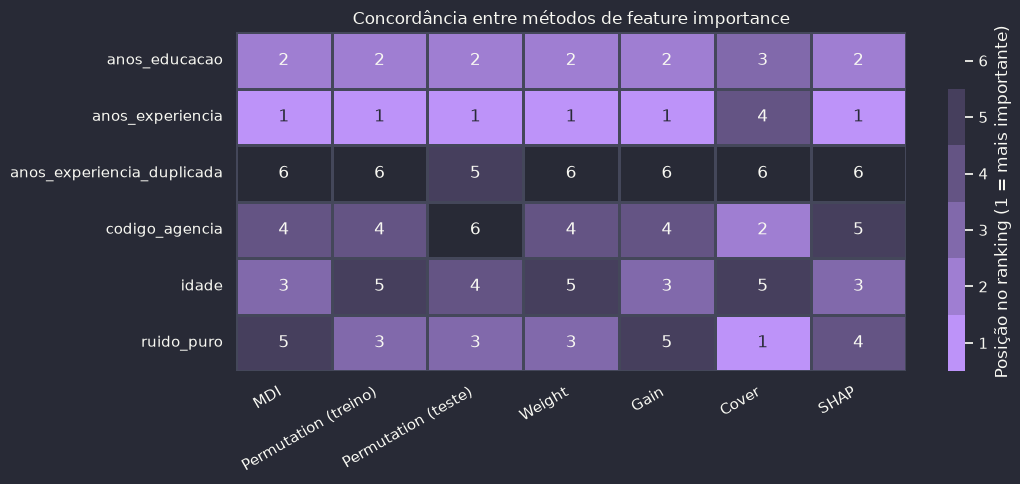

In [84]:
from matplotlib.colors import ListedColormap

DRACULA_PURPLE = "#bd93f9"
N_POSICOES = int(ranking.values.max())
ranking_colors = sns.blend_palette([DRACULA_PURPLE, DRACULA_BACKGROUND], n_colors=N_POSICOES)
ranking_cmap = ListedColormap(ranking_colors)

fig, ax = plt.subplots(figsize=(11, 5))

heatmap = sns.heatmap(
    ranking,
    annot=True,
    fmt=".0f",
    cmap=ranking_cmap,
    vmin=0.5,
    vmax=N_POSICOES + 0.5,
    linewidths=2,
    linecolor=DRACULA_GRID,
    cbar_kws={"label": "Posição no ranking (1 = mais importante)", "ticks": range(1, N_POSICOES + 1)},
    ax=ax,
)

for text, facecolor in zip(ax.texts, heatmap.collections[0].get_facecolors()):
    luminancia = 0.299 * facecolor[0] + 0.587 * facecolor[1] + 0.114 * facecolor[2]
    text.set_color(DRACULA_BACKGROUND if luminancia > 0.6 else DRACULA_FOREGROUND)

ax.set_title("Concordância entre métodos de feature importance")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig("../outputs/ranking_heatmap.png", dpi=150, facecolor=DRACULA_BACKGROUND)
plt.show()

## 10. Insights

**A feature de ruído aparece com importância não-nula em algum método?**

Sim, na maioria deles. No MDI, `ruido_puro` recebe 0,101, valor quase idêntico ao de `idade` (0,106), uma feature com relação real ao target. O mesmo padrão se repete no permutation importance calculado sobre o treino (0,188, acima inclusive de `idade`) e nos três tipos nativos do XGBoost, sendo o caso mais grave o `cover`, em que `ruido_puro` assume a **primeira posição** do ranking geral, à frente de todas as features legítimas. A única situação em que essa importância desaparece de fato é no permutation importance calculado sobre o **conjunto de teste**, onde cai para 0,007, valor estatisticamente indistinguível de zero.

**O que acontece com o ranking de `anos_experiencia` vs. `anos_experiencia_duplicada`?**

A duplicata recebe importância zero em absolutamente todos os sete métodos calculados, enquanto a variável original mantém sua posição de destaque (1º lugar em seis dos sete rankings). Isso ocorre porque a construção de uma árvore de decisão é gulosa: em cada nó, o algoritmo escolhe qual feature usar no split avaliando qual delas produz o maior ganho de pureza. Quando duas colunas são idênticas, ambas produzem exatamente o mesmo ganho, e o algoritmo resolve esse empate escolhendo consistentemente uma das duas (nesse caso, a original) e nunca alternando para a outra. O resultado prático é que nenhum método de importância, sozinho, sinaliza a existência de uma feature redundante: a duplicata simplesmente desaparece do radar. Isso poderia levar à falsa conclusão de que ela é irrelevante, quando na verdade carrega informação idêntica à variável mais importante do modelo.

**Os três rankings do XGBoost (weight, gain, cover) concordam entre si? Onde divergem?**

Não concordam. `gain` reproduz fielmente a hierarquia esperada (`anos_experiencia` domina com folga, seguida pelas demais features legítimas). `weight` já mostra sinais de viés: `ruido_puro` (932 splits) fica muito próximo de `anos_educacao` (1023), uma feature real. O caso mais extremo é `cover`, que inverte completamente a hierarquia: `ruido_puro` e `codigo_agencia` ocupam as duas primeiras posições, à frente de todas as features legítimas. A divergência se explica pela definição de cada métrica: `gain` mede a redução média de erro por split, o que favorece variáveis com efeito real forte; `weight` conta o número de splits, o que favorece variáveis com mais valores possíveis para dividir (como a categórica de alta cardinalidade); `cover` mede quantas amostras passam por cada split, o que também tende a favorecer variáveis que geram muitos splits ao longo da árvore, independentemente de esses splits carregarem sinal real.

**Permutation no treino vs. no teste: o viés de treino aparece?**

Sim, de forma bem clara. No treino, `ruido_puro` (0,188) e `codigo_agencia` (0,161) apresentam importância comparável à de `idade` (0,150), uma feature legítima. No teste, ambos colapsam: `ruido_puro` cai para 0,007 e `codigo_agencia` chega a ficar levemente negativo (-0,007). Isso é esperado para uma feature sem nenhum sinal real, já que embaralhá-la pode, por acaso, até melhorar ligeiramente a performance. Já as features legítimas mantêm importância relevante em ambos os conjuntos, embora também sofram alguma queda (`anos_experiencia` vai de 1,248 para 0,922; `anos_educacao`, de 0,262 para 0,081). Essa diferença generalizada entre treino e teste é a evidência direta de que o modelo memorizou parte do ruído específico da amostra de treino, comportamento que o MDI, por ser calculado inteiramente sobre o treino, não tem como capturar.

**SHAP corrige alguma inconsistência que os métodos anteriores mostraram?**

Corrige parcialmente. O SHAP restaura a ordem esperada entre as features legítimas e as armadilhas: `anos_experiencia`, `anos_educacao` e `idade` ocupam as três primeiras posições, com `ruido_puro` e `codigo_agencia` atrás de todas elas, desfazendo especificamente a inversão observada no `cover`. Ainda assim, o SHAP não zera a importância das duas armadilhas (`ruido_puro` = 194,2, `codigo_agencia` = 181,7); apenas as posiciona corretamente como as menos relevantes. Isso é coerente com a proposta teórica do método: SHAP garante *consistência* (o ranking não se inverte de forma arbitrária como acontece com `gain` e contagem de splits), mas não é um teste estatístico de significância: não elimina completamente o "ruído de estimação" que qualquer método baseado em uma amostra finita carrega.

**Qual método usar na prática?**

Dado o conjunto de resultados, MDI e os rankings brutos do XGBoost (especialmente `weight` e `cover`) não são confiáveis isoladamente para decidir descarte de features, por estarem sujeitos ao viés de treino e ao viés de alta cardinalidade. A combinação mais robusta é permutation importance sobre um conjunto de teste (ou validação) com SHAP: o primeiro expõe diretamente o que generaliza, o segundo oferece uma decomposição consistente por amostra. Por fim, um ranking de importância, de qualquer método, responde apenas "o quanto o modelo usou essa variável para prever, dado o conjunto de features presente no treino". Isso é diferente de "essa variável causa o resultado": alta importância pode refletir uma variável proxy de outra (como aconteceu aqui com a duplicata), vazamento de dados, ou uma associação que deixaria de existir se o conjunto de features mudasse. Importância de feature é uma medida de uso condicional ao modelo, não uma evidência causal.

**Uma ressalva sobre os próprios resultados deste notebook**

Como o dataset é simulado e o mecanismo gerador do target é conhecido (a fórmula da seção 2), não há risco de confundimento aqui: nenhuma feature parece importante só por estar correlacionada com outra que causa o resultado de verdade. A importância não-nula atribuída a `ruido_puro` e `codigo_agencia` em métodos como MDI, `weight` e `cover` é de outra natureza: reflete overfitting em amostra finita, o modelo encontrando padrões que existem apenas por acaso nos dados de treino, não relação real. Esse tipo de espuriedade é exatamente o que este exercício foi desenhado para expor, e só é possível prová-la com certeza porque o dataset é sintético e a verdade é conhecida de antemão. Em dados reais, sem esse controle, uma importância elevada nunca pode ser interpretada como prova de relação causal, apenas como um sinal a ser investigado.